In [1]:
# CELL 1 — Setup
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Research/glycemic-hybrid-ga

import os
import numpy as np
import matplotlib.pyplot as plt

# couleurs cohérentes
colors = {
    "ga_only": "blue",
    "ga_rules": "red",
    "ga_surrogate": "orange",
    "hybrid": "green",
}

# labels propres pour paper
labels_map = {
    "ga_only": "GA-only",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "GA+Surrogate",
    "hybrid": "Hybrid",
}

Mounted at /content/drive
/content/drive/MyDrive/Research/glycemic-hybrid-ga


In [2]:
# CELL 2 — Charger fichiers
results_path = "outputs/results"

files = [f for f in os.listdir(results_path) if f.endswith(".npy")]

print("NPY files found:", len(files))
print(files[:10])

NPY files found: 16
['G_S1_normal_ga_only.npy', 'G_S1_normal_ga_rules.npy', 'G_S1_normal_ga_surrogate.npy', 'G_S1_normal_hybrid.npy', 'G_S2_ramadan_ga_only.npy', 'G_S2_ramadan_ga_rules.npy', 'G_S2_ramadan_ga_surrogate.npy', 'G_S2_ramadan_hybrid.npy', 'G_S3_stress_highcarb_ga_only.npy', 'G_S3_stress_highcarb_ga_rules.npy']


In [3]:
# CELL 3 — Parser noms fichiers
def parse_filename(fname):
    name = fname.replace(".npy", "")
    name = name[2:]  # enlever "G_"

    parts = name.split("_")

    if parts[-1] == "only":
        method = "ga_only"
        scenario = "_".join(parts[:-2])
    elif parts[-1] == "rules":
        method = "ga_rules"
        scenario = "_".join(parts[:-2])
    elif parts[-1] == "surrogate":
        method = "ga_surrogate"
        scenario = "_".join(parts[:-2])
    elif parts[-1] == "hybrid":
        method = "hybrid"
        scenario = "_".join(parts[:-1])
    else:
        raise ValueError(f"Unknown file: {fname}")

    return scenario, method

In [4]:
# CELL 4 — Organiser données
data = {}

for f in files:
    scenario, method = parse_filename(f)
    path = os.path.join(results_path, f)

    G = np.load(path)

    if scenario not in data:
        data[scenario] = {}

    data[scenario][method] = G

# DEBUG
print(data["S3_stress_highcarb"].keys())

dict_keys(['ga_only', 'ga_rules', 'ga_surrogate', 'hybrid'])


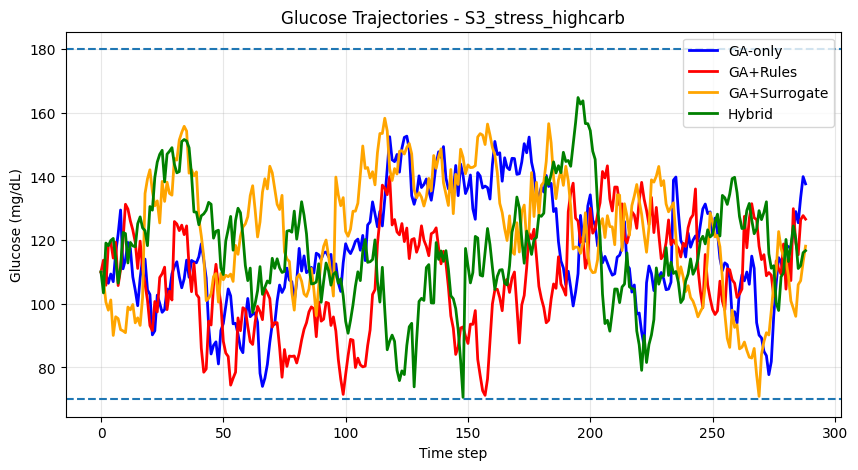

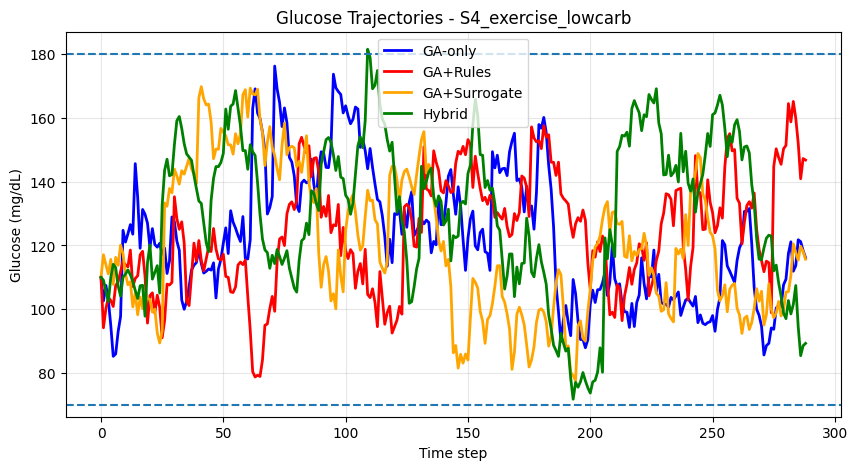

In [5]:
# CELL 5 — Trajectoires glucose

def plot_scenario(scenario_name):
    plt.figure(figsize=(10,5))

    methods = data[scenario_name]

    for method, G in methods.items():
        plt.plot(
            G,
            label=labels_map[method],
            color=colors[method],
            linewidth=2
        )

    # zones cliniques
    plt.axhline(70, linestyle="--")
    plt.axhline(180, linestyle="--")

    plt.title(f"Glucose Trajectories - {scenario_name}")
    plt.xlabel("Time step")
    plt.ylabel("Glucose (mg/dL)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


# plots principaux
plot_scenario("S3_stress_highcarb")
plot_scenario("S4_exercise_lowcarb")

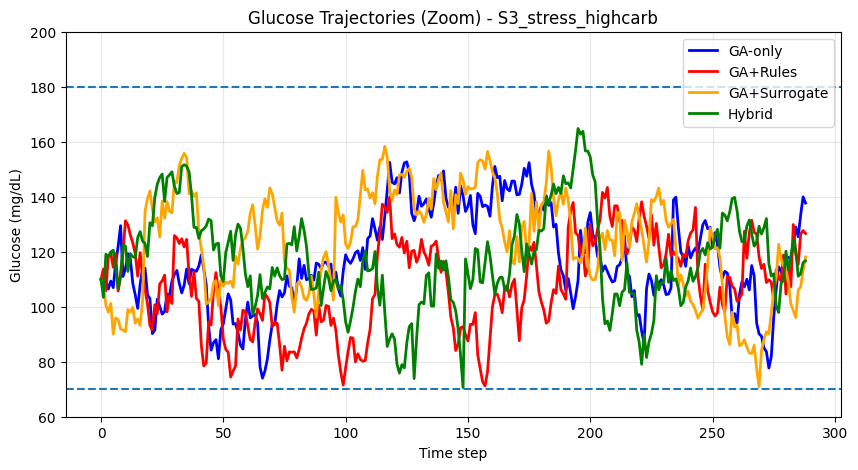

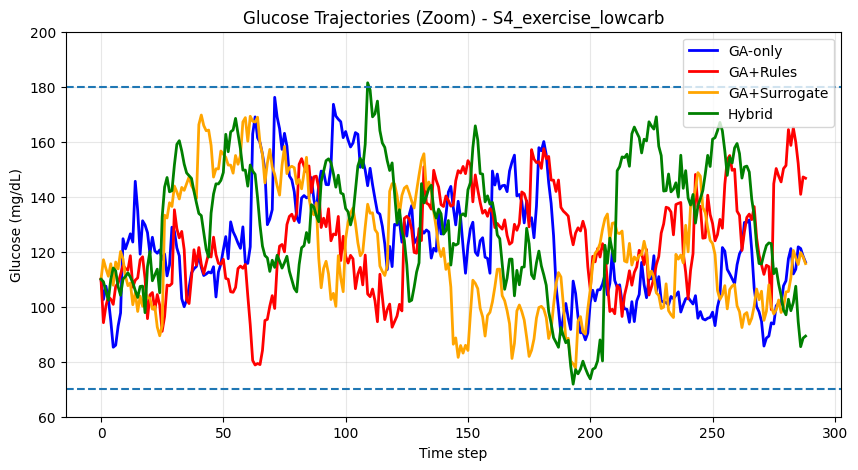

In [6]:
# CELL 6 — Zoom (meilleur pour paper)

def plot_zoom(scenario_name):
    plt.figure(figsize=(10,5))

    methods = data[scenario_name]

    for method, G in methods.items():
        plt.plot(
            G,
            label=labels_map[method],
            color=colors[method],
            linewidth=2
        )

    plt.axhline(70, linestyle="--")
    plt.axhline(180, linestyle="--")

    plt.ylim(60, 200)

    plt.title(f"Glucose Trajectories (Zoom) - {scenario_name}")
    plt.xlabel("Time step")
    plt.ylabel("Glucose (mg/dL)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


plot_zoom("S3_stress_highcarb")
plot_zoom("S4_exercise_lowcarb")

In [7]:
# CELL — Export automatic PDF figures

os.makedirs("figures", exist_ok=True)

selected = ["S3_stress_highcarb", "S4_exercise_lowcarb"]

def save_glucose_figure(scenario_name, zoom=False):
    plt.figure(figsize=(10,5))
    methods = data[scenario_name]

    order = ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]

    for method in order:
        if method in methods:
            plt.plot(
                methods[method],
                label=labels_map[method],
                color=colors[method],
                linewidth=2
            )

    plt.axhline(70, linestyle="--", color="black", linewidth=1)
    plt.axhline(180, linestyle="--", color="black", linewidth=1)

    if zoom:
        plt.ylim(60, 200)

    plt.title(f"Glucose Trajectories{' (Zoom)' if zoom else ''} - {scenario_name}")
    plt.xlabel("Time step")
    plt.ylabel("Glucose (mg/dL)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    suffix = "_zoom" if zoom else ""
    out = f"figures/glucose_{scenario_name}{suffix}.pdf"
    plt.savefig(out, bbox_inches="tight")
    plt.close()

    print("Saved:", out)

for scenario in selected:
    save_glucose_figure(scenario, zoom=False)
    save_glucose_figure(scenario, zoom=True)

Saved: figures/glucose_S3_stress_highcarb.pdf
Saved: figures/glucose_S3_stress_highcarb_zoom.pdf
Saved: figures/glucose_S4_exercise_lowcarb.pdf
Saved: figures/glucose_S4_exercise_lowcarb_zoom.pdf
